In [1]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

TRAIN_PARQUET_PATH = 'dataset/processed/AcTBeCalf/windowed_train.parquet'
TEST_PARQUET_PATH  = 'dataset/processed/AcTBeCalf/windowed_test.parquet'

for p in [TRAIN_PARQUET_PATH, TEST_PARQUET_PATH]:
    if os.path.exists(p):
        df_check = pd.read_parquet(p)
        print(f"Carregado: {p} | {df_check.shape[0]} janelas, {df_check.shape[1]} colunas")
    else:
        print(f"ERRO: Arquivo nao encontrado em {p}. Verifique o caminho.")

Carregado: dataset/processed/AcTBeCalf/windowed_train.parquet | 47771 janelas, 81 colunas
Carregado: dataset/processed/AcTBeCalf/windowed_test.parquet | 12985 janelas, 81 colunas


In [7]:
BATCH_SIZE = 64
NUM_WORKERS = 0

# ==============================================================================
# DATASET
# ==============================================================================
class CalfHybridDataset(Dataset):
    def __init__(self, signals, features, labels):
        """
        signals: Array Numpy (N, 3, 75)
        features: Array Numpy (N, 75)
        labels: Array Numpy (N,)
        """
        self.signals = torch.FloatTensor(signals)
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Retorna uma tupla: (Sinal Temporal, Features Estáticas, Label)
        return self.signals[idx], self.features[idx], self.labels[idx]

# ==============================================================================
# PIPELINE DE PREPARAÇÃO DE DADOS
# ==============================================================================
def prepare_dataloaders(train_parquet_path, test_parquet_path):
    standard_cols = ['dateTime', 'calfId', 'calf_id', 'segId', 'acc_x', 'acc_y', 'acc_z', 'label']

    def load_and_clean(path):
        df = pd.read_parquet(path)
        class_counts = df['label'].value_counts()
        to_remove = class_counts[class_counts < 2].index
        if len(to_remove) > 0:
            print(f"   Removendo classes com amostras insuficientes (<2): {list(to_remove)}")
            df = df[~df['label'].isin(to_remove)].reset_index(drop=True)
        return df

    print("1. Carregando Datasets...")
    df_train = load_and_clean(train_parquet_path)
    df_test  = load_and_clean(test_parquet_path)
    print(f"   Train: {len(df_train)} janelas | Test: {len(df_test)} janelas")

    feature_cols = [c for c in df_train.columns if c not in standard_cols]
    print(f"   Features TSFEL encontradas: {len(feature_cols)}")

    def extract(df):
        signals = np.stack([
            np.stack(df['acc_x'].values),
            np.stack(df['acc_y'].values),
            np.stack(df['acc_z'].values),
        ], axis=1).astype(np.float32)
        features = np.nan_to_num(df[feature_cols].values.astype(np.float32))
        return signals, features

    print("2. Processando Sinais e Features...")
    signals_tr, features_tr = extract(df_train)
    signals_te, features_te = extract(df_test)

    print("3. Codificando Labels...")
    le = LabelEncoder()
    le.fit(pd.concat([df_train['label'], df_test['label']]))
    labels_tr = le.transform(df_train['label'])
    labels_te = le.transform(df_test['label'])
    class_names = le.classes_
    print(f"   Classes ({len(class_names)}): {class_names}")

    # Split val from train only (90/10)
    train_idx, val_idx, _, _ = train_test_split(
        np.arange(len(df_train)), labels_tr, test_size=0.1, stratify=labels_tr, random_state=42
    )
    print(f"   Split: Treino={len(train_idx)}, Val={len(val_idx)}, Teste={len(labels_te)}")

    print("4. Normalizando Dados...")
    mean_signal = np.mean(signals_tr[train_idx], axis=(0, 2), keepdims=True)
    std_signal  = np.std(signals_tr[train_idx],  axis=(0, 2), keepdims=True)
    signals_tr_norm = (signals_tr - mean_signal) / (std_signal + 1e-6)
    signals_te_norm = (signals_te - mean_signal) / (std_signal + 1e-6)

    scaler_feats = StandardScaler()
    scaler_feats.fit(features_tr[train_idx])
    features_tr_norm = scaler_feats.transform(features_tr)
    features_te_norm = scaler_feats.transform(features_te)

    print("5. Criando Datasets e Dataloaders...")
    train_ds = CalfHybridDataset(signals_tr_norm[train_idx], features_tr_norm[train_idx], labels_tr[train_idx])
    val_ds   = CalfHybridDataset(signals_tr_norm[val_idx],   features_tr_norm[val_idx],   labels_tr[val_idx])
    test_ds  = CalfHybridDataset(signals_te_norm,            features_te_norm,            labels_te)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    return train_dl, val_dl, test_dl, class_names, len(feature_cols)

In [8]:
dl_train, dl_val, dl_test, classes, n_feats = prepare_dataloaders(TRAIN_PARQUET_PATH, TEST_PARQUET_PATH)

print("\n--- Teste de Integridade do DataLoader ---")
acc_batch, feat_batch, label_batch = next(iter(dl_train))

print(f"Batch Shapes:")
print(f"   Sinais (Input CNN):    {acc_batch.shape}  (Batch, Canais, Tempo)")
print(f"   Features (Input MLP):  {feat_batch.shape} (Batch, N_Features)")
print(f"   Labels:                {label_batch.shape}")

print(f"\nExemplo de Label: {label_batch[0]} -> {classes[label_batch[0]]}")

# Check de Normalização (Média deve ser proxima de 0 e Std proxima de 1)
print(f"\nStats do Batch de Sinais (Normalizado):")
print(f"   Média: {acc_batch.mean():.4f}, Std: {acc_batch.std():.4f}")

1. Carregando Datasets...
   Train: 47771 janelas | Test: 12985 janelas
   Features TSFEL encontradas: 75
2. Processando Sinais e Features...
3. Codificando Labels...
   Classes (17): ['Abnormal' 'Defecation' 'Drinking' 'Eating' 'Grooming' 'Lying'
 'Oral manipulation of pen' 'Play' 'Rising' 'Rumination' 'Run' 'SRS'
 'Sniff' 'Social Interaction' 'Standing' 'Urination' 'Walking']
   Split: Treino=42993, Val=4778, Teste=12985
4. Normalizando Dados...
5. Criando Datasets e Dataloaders...

--- Teste de Integridade do DataLoader ---
Batch Shapes:
   Sinais (Input CNN):    torch.Size([64, 3, 75])  (Batch, Canais, Tempo)
   Features (Input MLP):  torch.Size([64, 75]) (Batch, N_Features)
   Labels:                torch.Size([64])

Exemplo de Label: 14 -> Standing

Stats do Batch de Sinais (Normalizado):
   Média: -0.0387, Std: 0.9889


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class HybridCNNLSTM(nn.Module):
    def __init__(self, num_classes, n_features_tsfel, hidden_lstm=64):
        super(HybridCNNLSTM, self).__init__()
        
        # ==========================================
        # RAMO 1: SINAIS TEMPORAIS (CNN + LSTM)
        # Entrada: (Batch, 3, 75)
        # ==========================================
        # Bloco CNN (Feature Extractor)
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=3, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2) # Reduz dimensão temporal (75 -> 37)
        )
        
        # Bloco LSTM (Sequence Learner)
        # A entrada será (Batch, Time, Features) após a CNN
        self.lstm = nn.LSTM(
            input_size=128,    # Canais vindos da CNN
            hidden_size=hidden_lstm, 
            num_layers=2,      # Empilhar LSTMs ajuda em padrões complexos
            batch_first=True, 
            bidirectional=True, # Bidirecional é ótimo para classificação (vê passado e futuro da janela)
            dropout=0.3
        )
        
        # ==========================================
        # RAMO 2: FEATURES TSFEL (MLP)
        # Entrada: (Batch, 75)
        # ==========================================
        self.mlp_tsfel = nn.Sequential(
            nn.Linear(n_features_tsfel, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        
        # ==========================================
        # FUSÃO E CLASSIFICAÇÃO
        # ==========================================
        self.classifier = nn.Sequential(
            nn.Linear((hidden_lstm * 2) + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x_signal, x_features):
        # --- CAMINHO 1: CNN+LSTM --- (Batch, 3, 75)
        x_cnn = self.cnn(x_signal)      # Sai: (Batch, 128, 37)
        
        # Prepara para LSTM: PyTorch quer (Batch, Time, Features)
        x_cnn = x_cnn.permute(0, 2, 1)  # Sai: (Batch, 37, 128)
        lstm_out, _ = self.lstm(x_cnn)  # Sai: (Batch, 37, hidden*2)
        
        # Pega apenas o último passo temporal (o "resumo" da sequência)
        x_temporal = lstm_out[:, -1, :] # Sai: (Batch, hidden*2)
        
        # --- CAMINHO 2: TSFEL ---
        # x_features: (Batch, 75)
        x_static = self.mlp_tsfel(x_features) # Sai: (Batch, 64)
        
        # --- FUSÃO ---
        combined = torch.cat((x_temporal, x_static), dim=1)
        
        # --- CLASSIFICAÇÃO ---
        logits = self.classifier(combined)
        
        return logits

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Simula dados
BATCH_TEST = 32
N_CLASSES = 18 # `other` fraco. Só 1 janela
N_FEATS = 75

model = HybridCNNLSTM(num_classes=N_CLASSES, n_features_tsfel=N_FEATS).to(device)

dummy_signal = torch.randn(BATCH_TEST, 3, 75).to(device)
dummy_feats = torch.randn(BATCH_TEST, N_FEATS).to(device)

output = model(dummy_signal, dummy_feats)
print(f"Modelo Criado com Sucesso!")
print(f"Input Signal: {dummy_signal.shape}")
print(f"Input Features: {dummy_feats.shape}")
print(f"Output Logits: {output.shape} (Esperado: {BATCH_TEST}, {N_CLASSES})")

Modelo Criado com Sucesso!
Input Signal: torch.Size([32, 3, 75])
Input Features: torch.Size([32, 75])
Output Logits: torch.Size([32, 18]) (Esperado: 32, 18)


In [27]:
import torch.optim as optim
from tqdm import tqdm
import copy

def train_model(model, train_loader, val_loader, device, num_epochs=20):
    criterion = nn.CrossEntropyLoss()
    # AdamW costuma ser melhor que Adam puro para generalização
    optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-4)
    
    # Scheduler: Reduz LR se validação estagnar
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.1)
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        if (epoch+1) % 5 == 0:
            print(f'\nEpoch {epoch+1}/{num_epochs}')
            print('-' * 10)

        # --- TREINO ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for signals, features, labels in tqdm(train_loader, desc="Treinando"):
            signals = signals.to(device)
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward com DUAS entradas
            outputs = model(signals, features)
            loss = criterion(outputs, labels)

            loss.backward()
            
            # Gradient Clipping (Importante para LSTMs não explodirem)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            # Estatísticas
            running_loss += loss.item() * signals.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        if (epoch+1) % 5 == 0: 
            print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # --- VALIDAÇÃO ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for signals, features, labels in val_loader:
                signals = signals.to(device)
                features = features.to(device)
                labels = labels.to(device)

                outputs = model(signals, features)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * signals.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        if (epoch+1) % 5 == 0:
            print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        # Scheduler Step
        scheduler.step(val_loss)

        # Salva Melhor Modelo
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_hybrid_model.pth")
            print("💾 Melhor modelo salvo!")
            
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

    print(f'Melhor Val Acc: {best_acc:4f}')
    return model, history

# Instancia
model = HybridCNNLSTM(num_classes=len(classes), n_features_tsfel=n_feats).to(device)

# Treina
trained_model, hist = train_model(model, dl_train, dl_val, device)

Treinando: 100%|██████████| 672/672 [00:04<00:00, 135.91it/s]


💾 Melhor modelo salvo!


Treinando: 100%|██████████| 672/672 [00:04<00:00, 137.96it/s]


💾 Melhor modelo salvo!


Treinando: 100%|██████████| 672/672 [00:04<00:00, 135.44it/s]


...

💾 Melhor modelo salvo!


Treinando: 100%|██████████| 672/672 [00:04<00:00, 136.46it/s]



Epoch 20/20
----------


Treinando: 100%|██████████| 672/672 [00:04<00:00, 136.93it/s]


Train Loss: 1.0061 Acc: 0.6769
Val Loss: 0.8798 Acc: 0.7080
Melhor Val Acc: 0.715362


In [12]:
class RobustHybridModel(nn.Module):
    def __init__(self, num_classes, n_features_tsfel, hidden_lstm=128):
        super(RobustHybridModel, self).__init__()
        
        # ============================================================
        # RAMO 1: SINAIS (CNN + LSTM)
        # ============================================================
    
        self.cnn = nn.Sequential(
            # Bloco 1: (3 -> 64)
            nn.Conv1d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Reduz tamanho temporal (75 -> 37)
            
            # Bloco 2: (64 -> 128)
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Reduz tamanho temporal (37 -> 18)
            
            # Bloco 3: (128 -> 256)
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        
        # Sequence Learner (LSTM)
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=hidden_lstm,
            num_layers=1,      
            batch_first=True,   
            bidirectional=True  
        )
        
        # ============================================================
        # RAMO 2: FEATURES TSFEL (MLP Simples)
        # ============================================================
        self.mlp_tsfel = nn.Sequential(
            nn.Linear(n_features_tsfel, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5)  
        )
        
        # ============================================================
        # FUSÃO E CLASSIFICAÇÃO
        # ============================================================
        fusion_dim = (hidden_lstm * 2) + 128
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(m.weight)
        elif isinstance(m, nn.BatchNorm1d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

    def forward(self, x_signal, x_features):
        # 1. CNN
        features_cnn = self.cnn(x_signal)
        features_cnn = features_cnn.permute(0, 2, 1)
        
        # 2. LSTM
        lstm_out, (h_n, c_n) = self.lstm(features_cnn)
        
        # Pegamos a concatenação do último estado oculto forward e backward
        temporal_embedding = torch.cat((h_n[-2], h_n[-1]), dim=1) 
        static_embedding = self.mlp_tsfel(x_features)
        combined = torch.cat((temporal_embedding, static_embedding), dim=1)
        logits = self.classifier(combined)
        
        return logits

In [13]:
import torch
import torch.nn as nn

class TsfelOnlyModel(nn.Module):
    def __init__(self, num_classes, n_features_tsfel):
        super(TsfelOnlyModel, self).__init__()
        # ============================================================
        # APENAS RAMO TSFEL (MLP Profunda)
        # Entrada: (Batch, 75)
        # ============================================================
        self.mlp = nn.Sequential(
            # Camada 1: Expansão
            nn.Linear(n_features_tsfel, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Camada 2: Refinamento
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Camada 3: Compressão
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        
        # Classificador Final
        self.classifier = nn.Linear(64, num_classes)
        
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm1d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

    def forward(self, x_signal, x_features):
        # NOTA: O modelo recebe x_signal para manter compatibilidade com o loop de treino,
        # MAS IGNORA ELE COMPLETAMENTE.
        
        # Processa apenas features
        embedding = self.mlp(x_features)
        
        # Classifica
        logits = self.classifier(embedding)
        
        return logits

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import os
from sklearn.utils.class_weight import compute_class_weight

def train_robust_model_advanced(train_dl, val_dl, num_classes, n_feats, device, epochs=50, checkpoint_path="best_hybrid_model.pth"):
    print(f"🚀 Iniciando Treino Avançado (CNN+LSTM+TSFEL) no device: {device}")
    
    # 1. Instancia o Modelo
    model = TsfelOnlyModel(num_classes, n_feats).to(device)
    
    # ==============================================================================
    # 1.5. CHECKPOINT LOADING (WARM START)
    # ==============================================================================
    if os.path.exists(checkpoint_path):
        print(f"🔄 Checkpoint encontrado: '{checkpoint_path}'")
        try:
            # Carrega os pesos (map_location garante que carregue na CPU/GPU correta)
            state_dict = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(state_dict)
            print("✅ Pesos carregados com sucesso! O treino continuará de onde parou (Warm Start).")
        except Exception as e:
            print(f"⚠️ Erro ao carregar o arquivo (pode estar corrompido ou ser arquitetura diferente): {e}")
            print("   -> Iniciando treino do ZERO (pesos aleatórios).")
    else:
        print("✨ Nenhum checkpoint encontrado. Iniciando treino do ZERO.")

    # 2. Cálculo Automático de Pesos das Classes (Para Balanceamento)
    print("⚖️ Calculando pesos das classes para a Loss Function...")
    try:
        # Tenta pegar labels como numpy array
        all_labels = train_dl.dataset.labels.cpu().numpy()
        classes_unique = np.unique(all_labels)
        
        # 'balanced' calcula o inverso da frequência
        class_weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=all_labels)
        class_weights_tensor = torch.FloatTensor(class_weights).to(device)
        print(f"   Pesos calculados! (Ex: Classe 0 peso {class_weights[0]:.2f})")
    except Exception as e:
        print(f"   ⚠️ Aviso: Não foi possível calcular pesos automáticos ({e}). Usando pesos iguais.")
        class_weights_tensor = None

    # 3. Configuração de Otimização
    # Nota: Ao carregar um modelo, o AdamW vai "resetar" o momentum. 
    # Isso é bom para Fine-Tuning, pois dá um novo impulso na otimização.
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=5e-4)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.3
    )

    # 4. Variáveis de Controle
    # Inicializa o 'melhor modelo' com o estado atual (seja ele carregado ou novo)
    best_model_wts = copy.deepcopy(model.state_dict())
    
    # Para definir a best_acc inicial, fazemos uma validação rápida se carregamos pesos
    # Se não, começa com 0
    best_acc = 0.0
    
    early_stopping_patience = 25
    early_stopping_counter = 0

    # --- LOOP DE ÉPOCAS ---
    for epoch in range(epochs):
        model.train() # Modo Treino
        
        train_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (x_sig, x_feat, y) in enumerate(train_dl):
            x_sig, x_feat, y = x_sig.to(device), x_feat.to(device), y.to(device)
            
            if torch.isnan(x_sig).any() or torch.isnan(x_feat).any():
                print(f"❌ ERRO: NaNs no input (Batch {batch_idx}). Abortando.")
                return model
            
            optimizer.zero_grad()
            outputs = model(x_sig, x_feat)
            loss = criterion(outputs, y)
            
            if torch.isnan(loss):
                print("❌ ERRO: Loss virou NaN. Otimização explodiu.")
                return model

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item() * x_sig.size(0)
            _, pred = outputs.max(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)

        # Médias de Treino
        avg_train_loss = train_loss / len(train_dl.dataset)
        train_acc = 100. * correct / total

        # --- VALIDAÇÃO ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for x_sig, x_feat, y in val_dl:
                x_sig, x_feat, y = x_sig.to(device), x_feat.to(device), y.to(device)
                
                outputs = model(x_sig, x_feat)
                loss = criterion(outputs, y)
                
                val_loss += loss.item() * x_sig.size(0)
                _, pred = outputs.max(1)
                val_correct += pred.eq(y).sum().item()
                val_total += y.size(0)
        
        avg_val_loss = val_loss / len(val_dl.dataset)
        val_acc = 100. * val_correct / val_total
        
        # --- LOGS ---
        print(f"Ep {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.2f}%")
        
        scheduler.step(avg_val_loss)

        # --- CHECKPOINT & EARLY STOPPING ---
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), checkpoint_path)
            print(f"   💾 Novo Recorde! Modelo salvo em '{checkpoint_path}'. (Acc: {best_acc:.2f}%)")
            early_stopping_counter = 0 
        else:
            early_stopping_counter += 1
            
        if early_stopping_counter >= early_stopping_patience:
            print(f"\n🛑 Early Stopping ativado! Sem melhoria por {early_stopping_patience} épocas.")
            break

    print(f"\n🏁 Treino Finalizado. Melhor Acurácia de Validação: {best_acc:.2f}%")
    
    # Carrega os pesos do melhor modelo antes de retornar
    model.load_state_dict(best_model_wts)
    return model

# --- EXECUÇÃO ---
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

trained_model = train_robust_model_advanced(
    dl_train, dl_val, 
    num_classes=len(classes), 
    n_feats=n_feats, 
    device=device, 
    epochs=500
)

🚀 Iniciando Treino Avançado (CNN+LSTM+TSFEL) no device: mps
🔄 Checkpoint encontrado: 'best_hybrid_model.pth'
⚠️ Erro ao carregar o arquivo (pode estar corrompido ou ser arquitetura diferente): Error(s) in loading state_dict for TsfelOnlyModel:
	Missing key(s) in state_dict: "mlp.0.weight", "mlp.0.bias", "mlp.1.weight", "mlp.1.bias", "mlp.1.running_mean", "mlp.1.running_var", "mlp.4.weight", "mlp.4.bias", "mlp.5.weight", "mlp.5.bias", "mlp.5.running_mean", "mlp.5.running_var", "mlp.8.weight", "mlp.8.bias", "mlp.9.weight", "mlp.9.bias", "mlp.9.running_mean", "mlp.9.running_var", "classifier.weight", "classifier.bias". 
	Unexpected key(s) in state_dict: "cnn.0.weight", "cnn.0.bias", "cnn.1.weight", "cnn.1.bias", "cnn.1.running_mean", "cnn.1.running_var", "cnn.1.num_batches_tracked", "cnn.4.weight", "cnn.4.bias", "cnn.5.weight", "cnn.5.bias", "cnn.5.running_mean", "cnn.5.running_var", "cnn.5.num_batches_tracked", "lstm.weight_ih_l0", "lstm.weight_hh_l0", "lstm.bias_ih_l0", "lstm.bias_hh_l0

In [16]:
def train_finetune_stage2(train_dl, val_dl, num_classes, n_feats, device, epochs=20, checkpoint_path="best_hybrid_model.pth"):
    print(f"\nFINE-TUNING (Sem Pesos, LR Baixo)")
    
    # Instancia o Modelo
    model = TsfelOnlyModel(num_classes, n_feats).to(device)
    
    # Carrega o Modelo Treinado no Estágio 1
    if os.path.exists(checkpoint_path):
        print(f"🔄 Carregando pesos do Estágio 1: '{checkpoint_path}'")
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
    else:
        return None

    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
    print("Loss Function: Padrão (Sem pesos de classe) -> Foco em Acurácia Global")
    criterion = nn.CrossEntropyLoss(weight=None)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    finetune_path = "best_hybrid_finetuned.pth"
    best_acc = 0.0 
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        
        for x_sig, x_feat, y in train_dl:
            x_sig, x_feat, y = x_sig.to(device), x_feat.to(device), y.to(device)
            
            optimizer.zero_grad()
            outputs = model(x_sig, x_feat)
            loss = criterion(outputs, y)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item() * x_sig.size(0)
            _, pred = outputs.max(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)

        avg_train_loss = train_loss / len(train_dl.dataset)
        train_acc = 100. * correct / total

        # Validação
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for x_sig, x_feat, y in val_dl:
                x_sig, x_feat, y = x_sig.to(device), x_feat.to(device), y.to(device)
                outputs = model(x_sig, x_feat)
                loss = criterion(outputs, y)
                val_loss += loss.item() * x_sig.size(0)
                _, pred = outputs.max(1)
                val_correct += pred.eq(y).sum().item()
                val_total += y.size(0)
        
        avg_val_loss = val_loss / len(val_dl.dataset)
        val_acc = 100. * val_correct / val_total
        
        print(f"Fine-Tune Ep {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.2f}%")
        
        scheduler.step(avg_val_loss)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), finetune_path)
            print(f"    Novo Recorde (Fine-Tune)! Salvo em '{finetune_path}'.")

    print(f"\nFine-Tuning Finalizado. Melhor Acurácia: {best_acc:.2f}%")
    return model

# Fine-Tuning (Estágio 2)
finetuned_model = train_finetune_stage2(
    dl_train, dl_val, 
    num_classes=len(classes), 
    n_feats=n_feats, 
    device=device, 
    epochs=50
)


FINE-TUNING (Sem Pesos, LR Baixo)
🔄 Carregando pesos do Estágio 1: 'best_hybrid_model.pth'
Loss Function: Padrão (Sem pesos de classe) -> Foco em Acurácia Global
Fine-Tune Ep 01 | Train Loss: 0.9262 Acc: 69.28% | Val Loss: 0.7685 Acc: 74.51%
    Novo Recorde (Fine-Tune)! Salvo em 'best_hybrid_finetuned.pth'.
Fine-Tune Ep 02 | Train Loss: 0.8898 Acc: 70.31% | Val Loss: 0.7572 Acc: 74.61%
    Novo Recorde (Fine-Tune)! Salvo em 'best_hybrid_finetuned.pth'.
Fine-Tune Ep 03 | Train Loss: 0.8811 Acc: 70.60% | Val Loss: 0.7544 Acc: 74.82%
    Novo Recorde (Fine-Tune)! Salvo em 'best_hybrid_finetuned.pth'.
Fine-Tune Ep 04 | Train Loss: 0.8718 Acc: 70.85% | Val Loss: 0.7536 Acc: 74.49%
Fine-Tune Ep 05 | Train Loss: 0.8701 Acc: 70.97% | Val Loss: 0.7511 Acc: 74.63%
Fine-Tune Ep 06 | Train Loss: 0.8751 Acc: 70.81% | Val Loss: 0.7515 Acc: 74.51%
Fine-Tune Ep 07 | Train Loss: 0.8677 Acc: 71.15% | Val Loss: 0.7530 Acc: 74.88%
    Novo Recorde (Fine-Tune)! Salvo em 'best_hybrid_finetuned.pth'.
Fine-


INICIANDO AVALIAÇÃO FINAL NO DATASET DE TESTE
   Modelo alvo: best_hybrid_finetuned.pth

RESULTADO FINAL (TEST SET)
Acurácia Global: 70.16%
Loss Média:      0.9120
                          precision    recall  f1-score   support

                Abnormal       0.00      0.00      0.00        51
              Defecation       0.00      0.00      0.00        10
                Drinking       0.60      0.54      0.57      1063
                  Eating       0.47      0.48      0.48      2007
                Grooming       0.61      0.59      0.60       665
                   Lying       0.92      0.92      0.92      6271
Oral manipulation of pen       0.25      0.37      0.30       385
                    Play       0.50      0.60      0.55        96
                  Rising       0.45      0.23      0.30        22
              Rumination       0.00      0.00      0.00         0
                     Run       0.96      0.99      0.98       319
                     SRS       0.46      0

/var/folders/xf/3z7cg77s3r947td4rtbw2y3m0000gn/T/ipykernel_20088/4233627727.py:74: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


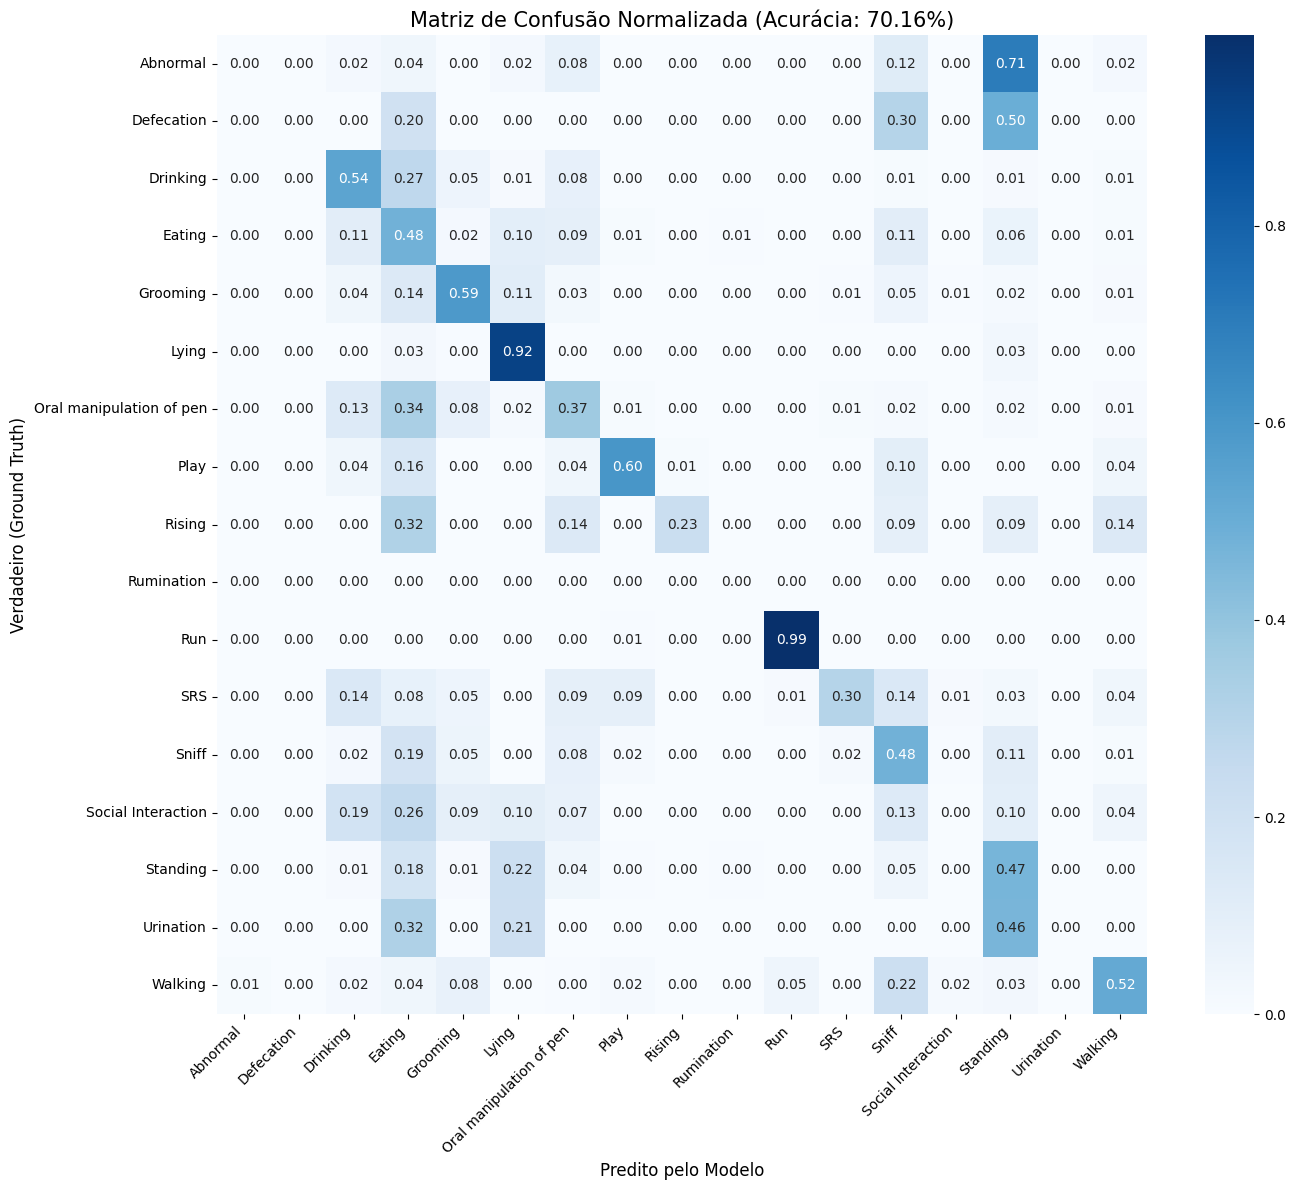

In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

def evaluate_on_test(test_dl, num_classes, n_feats, device, checkpoint_path="best_hybrid_finetuned.pth", class_names=None):
    print(f"\nINICIANDO AVALIAÇÃO FINAL NO DATASET DE TESTE")
    print(f"   Modelo alvo: {checkpoint_path}")
    
    # 1nstancia o Modelo 
    model = TsfelOnlyModel(num_classes, n_feats).to(device)
    if os.path.exists(checkpoint_path):
        try:
            state_dict = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(state_dict)
        except Exception as e:
            print(f"Erro ao carregar pesos: {e}")
            return
    else:
        fallback = "best_hybrid_model.pth"
        if os.path.exists(fallback):
            print(f"'{checkpoint_path}' não encontrado. Usando '{fallback}'...")
            model.load_state_dict(torch.load(fallback, map_location=device))
        else:
            print("Nenhum checkpoint encontrado!")
            return

    # Loop de Predição
    model.eval() 
    
    criterion = nn.CrossEntropyLoss()
    test_loss = 0.0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_sig, x_feat, y in test_dl:
            x_sig, x_feat, y = x_sig.to(device), x_feat.to(device), y.to(device)
            
            # Forward
            outputs = model(x_sig, x_feat)
            loss = criterion(outputs, y)
            
            test_loss += loss.item() * x_sig.size(0)
            
            # Pega a classe com maior probabilidade
            _, preds = torch.max(outputs, 1)
            
            # Guarda na CPU para usar no Scikit-Learn
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    # Médias
    avg_loss = test_loss / len(test_dl.dataset)
    acc = accuracy_score(all_labels, all_preds)
    
    print("\n" + "="*50)
    print(f"RESULTADO FINAL (TEST SET)")
    print("="*50)
    print(f"Acurácia Global: {acc:.2%}")
    print(f"Loss Média:      {avg_loss:.4f}")
    
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
    
    # Matriz de Confusão
    cm = confusion_matrix(all_labels, all_preds)
    
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f'Matriz de Confusão Normalizada (Acurácia: {acc:.2%})', fontsize=15)
    plt.xlabel('Predito pelo Modelo', fontsize=12)
    plt.ylabel('Verdadeiro (Ground Truth)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

evaluate_on_test(dl_test, 
                 num_classes=len(classes), 
                 n_feats=n_feats, 
                 device=device, 
                 checkpoint_path="best_hybrid_finetuned.pth",
                 class_names=classes)

In [18]:
!pip install tsfel

In [ ]:
import tsfel
import warnings
import pyarrow.parquet as pq
import gc
from numpy.lib.stride_tricks import sliding_window_view

INPUT_PATH = 'dataset/processed/AcTBeCalf/Time_Adj_Raw_Data.parquet'
OUTPUT_PATH = 'dataset/processed/AcTBeCalf/Windowed_Time_Adj.parquet'
TEMP_DIR = 'temp_chunks'
WINDOW_SIZE = 75
OVERLAP = 0.50
STRIDE = int(WINDOW_SIZE * (1 - OVERLAP))
CHUNK_SIZE = 500000 

# Lista exata das 75 features
SELECTED_FEATURES = [
    "accX_Entropy",
    "accX_Signal distance",
    "accY_Entropy",
    "accY_Peak to peak distance",
    "accZ_Signal distance",
    "accZ_Entropy",
    "accX_Peak to peak distance",
    "accX_Interquartile range",
    "accY_Signal distance",
    "accZ_Sum absolute diff",
    "accX_Spectral decrease",
    "accX_Spectral centroid",
    "accX_Spectral spread",
    "accZ_Spectral decrease",
    "accY_Sum absolute diff",
    "accY_ECDF Percentile_1",
    "accY_Histogram mode",
    "accZ_Peak to peak distance",
    "accY_Max",
    "accY_Spectral decrease",
    "accY_ECDF Percentile_0",
    "accY_Min",
    "accX_Spectral distance",
    "accX_Wavelet energy_1.56Hz",
    "accX_Maximum frequency",
    "accY_Area under the curve",
    "accX_Wavelet variance_1.56Hz",
    "accX_Spectrogram mean coefficient_2.02Hz",
    "accY_Absolute energy",
    "accY_Wavelet energy_0.69Hz",
    "accY_Spectral spread",
    "accY_Spectral centroid",
    "accX_Wavelet energy_1.25Hz",
    "accX_Positive turning points",
    "accY_Spectral distance",
    "accZ_Spectral spread",
    "accX_Root mean square",
    "accY_Spectral variation",
    "accY_MFCC_0",
    "accX_Max",
    "accX_Mean",
    "accX_Area under the curve",
    "accX_Wavelet variance_1.25Hz",
    "accX_Wavelet energy_1.04Hz",
    "accZ_ECDF Percentile_1",
    "accX_Spectral entropy",
    "accX_Absolute energy",
    "accX_Wavelet variance_1.04Hz",
    "accZ_Max",
    "accZ_Spectral centroid",
    "accX_Autocorrelation",
    "accY_Maximum frequency",
    "accZ_ECDF Percentile_0",
    "accX_Wavelet energy_0.69Hz",
    "accZ_Min",
    "accZ_Wavelet variance_1.56Hz",
    "accZ_Absolute energy",
    "accY_LPCC_1",
    "accX_Negative turning points",
    "accX_Histogram mode",
    "accZ_Area under the curve",
    "accY_Negative turning points",
    "accX_ECDF Percentile_1",
    "accY_Autocorrelation",
    "accX_MFCC_1",
    "accZ_Wavelet energy_0.69Hz",
    "accZ_Wavelet variance_2.08Hz",
    "accZ_MFCC_1",
    "accX_MFCC_0",
    "accZ_MFCC_0",
    "accX_Min",
    "accY_Spectral entropy",
    "accY_MFCC_1",
    "accX_Spectral variation",
    "accY_Power bandwidth"
]
def get_optimized_tsfel_config():
    """ 
    Cria um config que SÓ calcula o que precisamos. 
    """
    cfg_all = tsfel.get_features_by_domain()
    
    # MUDANÇA: Inicializa vazio para aceitar qualquer domínio novo (ex: 'fractal')
    cfg_filtered = {}
    
    # Extrai nomes base únicos das features desejadas
    target_bases = set()
    for feat in SELECTED_FEATURES:
        if '_' in feat:
            base = feat.split('_', 1)[1] 
        else:
            base = feat
            
        target_bases.add(base)
        if '_' in base:
            target_bases.add(base.split('_')[0])

    # Filtra o dicionário
    count = 0
    for domain, features in cfg_all.items():
        for feat_name, feat_params in features.items():
            # Verifica se essa feature está na nossa lista alvo
            if feat_name in target_bases or any(t in feat_name for t in target_bases):
                if domain not in cfg_filtered:
                    cfg_filtered[domain] = {}
                cfg_filtered[domain][feat_name] = feat_params
                count += 1
                
    print(f"Config TSFEL: {count} funções base selecionadas.")
    return cfg_filtered

# Cria o config global uma vez
CFG_OPTIMIZED = get_optimized_tsfel_config()
os.makedirs(TEMP_DIR, exist_ok=True)

def process_chunk_vectorized(df_chunk, chunk_id):
    """ Processamento Vetorizado + Config Otimizada """
    
    # Dados para Numpy
    data = df_chunk[['accX', 'accY', 'accZ']].values.astype(np.float32)
    times = df_chunk['dateTime'].values
    
    try:
        # window_axis=0 pois queremos deslizar nas linhas
        windows_view = sliding_window_view(data, window_shape=(WINDOW_SIZE, 3))
        windows = windows_view[::STRIDE, 0, :, :]
        
        # Pega os timestamps iniciais correspondentes
        times_window = times[:len(data) - WINDOW_SIZE + 1][::STRIDE]
    except ValueError:
        return None # Chunk muito pequeno

    if len(windows) == 0: return None

    # Prepara listas para o DataFrame final
    acc_x_list = list(windows[:, :, 0])
    acc_y_list = list(windows[:, :, 1])
    acc_z_list = list(windows[:, :, 2])

    df_win = pd.DataFrame({
        'dateTime': times_window,
        'acc_x': acc_x_list,
        'acc_y': acc_y_list,
        'acc_z': acc_z_list,
        'label': -1
    })

    # Extração TSFEL Otimizada
    tsfel_input = [pd.DataFrame(w, columns=['accX', 'accY', 'accZ']) for w in windows]
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            # USA O CFG OTIMIZADO AQUI!
            X_feat = tsfel.time_series_features_extractor(
                CFG_OPTIMIZED, tsfel_input, fs=25, n_jobs=-1
            )
        except Exception as e:
            print(f"⚠️ Erro TSFEL Chunk {chunk_id}: {e}")
            return None

    # Limpeza
    X_feat = X_feat.astype(np.float32).fillna(0)
    cols_to_keep = [c for c in X_feat.columns if c in SELECTED_FEATURES]
    X_feat = X_feat[cols_to_keep]
    
    # Cria colunas faltantes com 0 (caso alguma feature complexa tenha falhado)
    for col in SELECTED_FEATURES:
        if col not in X_feat.columns: X_feat[col] = 0.0
    X_feat = X_feat[SELECTED_FEATURES]

    # Salva Chunk
    df_final = pd.concat([df_win, X_feat], axis=1)
    save_path = os.path.join(TEMP_DIR, f'chunk_{chunk_id}.parquet')
    df_final.to_parquet(save_path, index=False)
    
    del windows, tsfel_input, X_feat, df_final
    gc.collect()
    
    print(f"   -> Chunk {chunk_id} salvo ({len(df_win)} janelas).")
    return save_path

print(os.path.exists(INPUT_PATH))

if os.path.exists(INPUT_PATH):
    print(f"🚀 Processando {INPUT_PATH} com Otimização Máxima...")
    parquet_file = pq.ParquetFile(INPUT_PATH)
    chunk_files = []
    
    # SUBSAMPLING
    SKIP_FACTOR = 1 
    
    for i, batch in enumerate(parquet_file.iter_batches(batch_size=CHUNK_SIZE)):
        if i % SKIP_FACTOR != 0: continue
            
        print(f"\n📦 Batch {i}...")
        df_chunk = batch.to_pandas()
        saved = process_chunk_vectorized(df_chunk, i)
        if saved: chunk_files.append(saved)
        
        del df_chunk
        gc.collect()

    if chunk_files:
        import pyarrow as pa
        tables = [pq.read_table(f) for f in chunk_files]
        full_table = pa.concat_tables(tables)
        pq.write_table(full_table, OUTPUT_PATH, compression='snappy')
        print(f"\n✅ Processamento Completo! Arquivo salvo em '{OUTPUT_PATH}'.")
        
        print("Sucesso!")
        for f in chunk_files: os.remove(f)
        os.rmdir(TEMP_DIR)
    else:
        print("Nada processado.")
else:
    print("Arquivo não encontrado.")

Config TSFEL: 35 funções base selecionadas.
False
Arquivo não encontrado.


In [34]:
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
import os
import shutil

TEMP_DIR = 'temp_chunks'  # A pasta onde os chunks estão sendo salvos
OUTPUT_PATH = 'Windowed_Time_Adj.parquet'

def rescue_processed_data():
    print(f"Iniciando operação de resgate em '{TEMP_DIR}'...")
    
    if not os.path.exists(TEMP_DIR):
        print("Diretório temporário não encontrado.")
        return

    # Lista todos os arquivos parquet parciais
    chunk_files = [
        os.path.join(TEMP_DIR, f) 
        for f in os.listdir(TEMP_DIR) 
        if f.endswith('.parquet')
    ]
    
    # Ordena para manter a ordem temporal
    try:
        chunk_files.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))
    except:
        pass
        
    count = len(chunk_files)
    print(f"Encontrados {count} chunks processados")
    
    if count == 0:
        print("Nenhum arquivo para salvar")
        return
    
    try:
        tables = []
        for i, f in enumerate(chunk_files):
            try:
                t = pq.read_table(f)
                tables.append(t)
            except Exception as e:
                print(f" Chunk {f} corrompido ou incompleto. Ignorando. Erro: {e}")
        
        if not tables:
            print("Nenhum chunk válido para unir.")
            return

        full_table = pa.concat_tables(tables)
        
        print(f"Salvando arquivo final em: {OUTPUT_PATH}...")
        pq.write_table(full_table, OUTPUT_PATH, compression='snappy')
        
        print("\nDataset salvo e pronto para uso")
        print(f"   Total de Janelas Recuperadas: {full_table.num_rows}")
        print(f"   Total de Colunas: {full_table.num_columns}")
        
    except Exception as e:
        print(f"Erro fatal ao unir arquivos: {e}")

rescue_processed_data()

Iniciando operação de resgate em 'temp_chunks'...
Encontrados 1 chunks processados
Salvando arquivo final em: Windowed_Time_Adj.parquet...

Dataset salvo e pronto para uso
   Total de Janelas Recuperadas: 13512
   Total de Colunas: 80


In [35]:

class SensorFixMatchAugment:
    def __init__(self, device):
        self.device = device

    def weak_aug(self, x_signal, x_features):
        """
        Sinal: Adiciona ruído gaussiano e escala amplitude.
        Features: Adiciona ruído muito leve (apenas para robustez).
        """
        B, C, T = x_signal.shape
        
        # Jittering (Ruído Aditivo)
        noise = torch.randn_like(x_signal) * 0.05
        
        # Scaling (Ruído Multiplicativo)
        scale = torch.rand(B, 1, 1, device=self.device) * 0.2 + 0.9
        aug_signal = (x_signal * scale) + noise
        aug_features = x_features + (torch.randn_like(x_features) * 0.02)
        
        return aug_signal, aug_features

    def strong_aug(self, x_signal, x_features):
        """
        Sinal: Permutação de segmentos ou Time Masking.
        Features: Ruído um pouco maior.
        """
        # Aplica Weak primeiro para ter variabilidade base
        x_s, x_f = self.weak_aug(x_signal, x_features)
        
        B, C, T = x_s.shape
        x_aug = x_s.clone()
        
        # Escolhe aleatoriamente entre Permutation ou Masking
        if np.random.rand() > 0.5:
            if T > 10:
                num_segments = np.random.randint(2, 5)
                seg_len = T // num_segments
                for i in range(B):
                    perm = torch.randperm(num_segments)
                    temp = []
                    for p in perm:
                        temp.append(x_s[i, :, p*seg_len : (p+1)*seg_len])
                    
                    shuffled = torch.cat(temp, dim=1)
                    # Ajuste de tamanho (padding/crop)
                    if shuffled.shape[1] < T:
                        pad = torch.zeros(C, T - shuffled.shape[1], device=self.device)
                        shuffled = torch.cat([shuffled, pad], dim=1)
                    elif shuffled.shape[1] > T:
                        shuffled = shuffled[:, :T]
                    x_aug[i] = shuffled
        else:
            # Time Masking (Zera um bloco)
            mask_len = int(T * 0.3)
            for i in range(B):
                start = np.random.randint(0, T - mask_len)
                x_aug[i, :, start : start+mask_len] = 0.0
        
        # Features sofrem um pouco mais de ruído no Strong
        f_aug = x_f + (torch.randn_like(x_f) * 0.05)
        
        return x_aug, f_aug

In [36]:
class UnlabeledDataset(Dataset):
    def __init__(self, signals, features):
        self.signals = torch.FloatTensor(signals)
        self.features = torch.FloatTensor(features)

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        return self.signals[idx], self.features[idx]

def prepare_unlabeled_dataloader(unlabeled_parquet_path, labeled_dl, batch_size=64):
    print("📂 Carregando dados não rotulados...")
    df_u = pd.read_parquet(unlabeled_parquet_path)
    
    # Separa colunas
    standard_cols = ['dateTime', 'calfId', 'calf_id', 'segId', 'acc_x', 'acc_y', 'acc_z', 'label']
    feat_cols = [c for c in df_u.columns if c not in standard_cols]
    
    print(f"   Amostras Unlabeled: {len(df_u)}")
    print(f"   Features TSFEL: {len(feat_cols)}")

    x_stack = np.stack(df_u['acc_x'].values)
    y_stack = np.stack(df_u['acc_y'].values)
    z_stack = np.stack(df_u['acc_z'].values)
    signals_u = np.stack([x_stack, y_stack, z_stack], axis=1).astype(np.float32)
    
    features_u = df_u[feat_cols].values.astype(np.float32)
    features_u = np.nan_to_num(features_u)
    
    # RECUPERAÇÃO DA NORMALIZAÇÃO (DO LABELED)
    print("🔄 Recuperando estatísticas de normalização do dataset rotulado...")
    mean_sig = np.mean(signals_u, axis=(0, 2), keepdims=True)
    std_sig = np.std(signals_u, axis=(0, 2), keepdims=True)
    signals_norm = (signals_u - mean_sig) / (std_sig + 1e-6)
    
    # Para features, usamos StandardScaler fitado no Unlabeled
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_u)
    
    # DATALOADER 
    ds_u = UnlabeledDataset(signals_norm, features_norm)
    dl_u = DataLoader(ds_u, batch_size=batch_size*7, shuffle=True, num_workers=0, drop_last=True)
    
    return dl_u

In [42]:
def train_fixmatch(labeled_dl, unlabeled_dl, val_dl, num_classes, n_feats, device, 
                   epochs=20, checkpoint_path="best_hybrid_finetuned.pth", 
                   threshold=0.95, lambda_u=1.0):
    
    print(f"\nINICIANDO TREINO FIXMATCH")
    print(f"   Threshold: {threshold} | Lambda_U: {lambda_u}")
    model = RobustHybridModel(num_classes, n_feats).to(device)
    
    if os.path.exists(checkpoint_path):
        print(f"🔄 Carregando pesos pré-treinados: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    else:
        print("⚠️ Aviso: Checkpoint não encontrado. Iniciando do zero (não recomendado para FixMatch).")

    # Otimizador
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    augmenter = SensorFixMatchAugment(device)
    
    # Iterador infinito para unlabeled
    def cycle(iterable):
        while True:
            for x in iterable: yield x
    unlabeled_iter = cycle(unlabeled_dl)
    
    best_acc = 0.0
    save_path = "best_fixmatch_model.pth"

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_loss_s = 0
        total_loss_u = 0
        mask_count = 0
        total_steps = 0
        
        # O loop segue o tamanho do dataset ROTULADO
        for batch_idx, (x_s_lab, x_f_lab, y_lab) in enumerate(labeled_dl):
            x_s_lab = x_s_lab.to(device)
            x_f_lab = x_f_lab.to(device)
            y_lab = y_lab.to(device)
            
            # Pega batch não rotulado
            x_s_unlab, x_f_unlab = next(unlabeled_iter)
            x_s_unlab = x_s_unlab.to(device)
            x_f_unlab = x_f_unlab.to(device)
            
            curr_batch_size = x_s_lab.size(0)
            x_s_unlab = x_s_unlab[:curr_batch_size]
            x_f_unlab = x_f_unlab[:curr_batch_size]
            
            # ==========================================
            # PARTE 1: SUPERVISIONADO (Labeled)
            # ==========================================
            x_s_lab_aug, x_f_lab_aug = augmenter.weak_aug(x_s_lab, x_f_lab)
            logits_lab = model(x_s_lab_aug, x_f_lab_aug)
            loss_s = F.cross_entropy(logits_lab, y_lab)
            
            # ==========================================
            # PARTE 2: NÃO SUPERVISIONADO (FixMatch)
            # ==========================================
            with torch.no_grad():
                x_s_weak, x_f_weak = augmenter.weak_aug(x_s_unlab, x_f_unlab)
                logits_weak = model(x_s_weak, x_f_weak)
                probs_weak = torch.softmax(logits_weak, dim=1)
                max_probs, pseudo_labels = torch.max(probs_weak, dim=1)
                
                # Máscara: Só confiamos se prob > threshold
                mask = max_probs.ge(threshold).float()
                mask_count += mask.mean().item()
            
            x_s_strong, x_f_strong = augmenter.strong_aug(x_s_unlab, x_f_unlab)
            logits_strong = model(x_s_strong, x_f_strong)

            loss_u_unreduced = F.cross_entropy(logits_strong, pseudo_labels, reduction='none')
            loss_u = (loss_u_unreduced * mask).mean()
            
            # ==========================================
            # OTIMIZAÇÃO
            # ==========================================
            loss = loss_s + (lambda_u * loss_u)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            total_loss_s += loss_s.item()
            total_loss_u += loss_u.item()
            total_steps += 1
            
        # --- VALIDAÇÃO ---
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for x_s, x_f, y in val_dl:
                x_s, x_f, y = x_s.to(device), x_f.to(device), y.to(device)
                outputs = model(x_s, x_f)
                _, pred = outputs.max(1)
                val_correct += pred.eq(y).sum().item()
                val_total += y.size(0)
        
        val_acc = 100 * val_correct / val_total
        
        # Stats da Época
        avg_mask = mask_count / total_steps
        print(f"Ep {epoch+1:02d} | Loss: {total_loss/total_steps:.4f} (Sup: {total_loss_s/total_steps:.3f} | Unsup: {total_loss_u/total_steps:.3f}) | Mask Rate: {avg_mask:.1%} | Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"   💾 Modelo FixMatch salvo! ({best_acc:.2f}%)")

    return model

# --- EXECUÇÃO ---
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# 1. Carrega Dataloader Unlabeled
# (Certifique-se de que dl_train existe do passo anterior)
if 'dl_train' in locals():
    dl_unlabeled = prepare_unlabeled_dataloader(
        unlabeled_parquet_path='dataset/processed/AcTBeCalf/Windowed_Time_Adj.parquet',
        labeled_dl=dl_train,
        batch_size=128
    )

    # 2. Roda FixMatch
    # n_feats e num_classes vêm do código anterior
    fixmatch_model = train_fixmatch(
        labeled_dl=dl_train,
        unlabeled_dl=dl_unlabeled,
        val_dl=dl_val,
        num_classes=len(classes),
        n_feats=n_feats,
        device=device,
        epochs=200, 
        threshold=0.90,
        lambda_u=1
    )
else:
    print("Erro: Dataloaders supervisionados não encontrados.")

📂 Carregando dados não rotulados...


FileNotFoundError: [Errno 2] No such file or directory: 'dataset/processed/AcTBeCalf/Windowed_Time_Adj.parquet'

In [38]:
FILE_PATH = TRAIN_PARQUET_PATH #'dataset/processed/AcTBeCalf/Windowed_Time_Adj.parquet'

try:
    df = pd.read_parquet(FILE_PATH)
    
    print(f"Shape total do DataFrame: {df.shape}")
    
    # Lista de todas as colunas no arquivo
    all_cols = df.columns.tolist()
    standard_cols = ['dateTime', 'calfId', 'calf_id', 'segId', 'acc_x', 'acc_y', 'acc_z', 'label']
    
    # Identifica quais colunas sao metadata e quais sao features
    found_standard = [c for c in all_cols if c in standard_cols]
    feature_cols = [c for c in all_cols if c not in standard_cols]
    
    print("\n--- COLUNAS DE METADADOS ENCONTRADAS ---")
    print(found_standard)
    
    print("\n--- ANALISE DE FEATURES (TSFEL) ---")
    print(f"Numero esperado de features: 75")
    print(f"Numero real de features encontradas: {len(feature_cols)}")
    
    if len(feature_cols) != 75:
        print(f"!!! ALERTA: Diferenca de {len(feature_cols) - 75} coluna(s) !!!")
    
    print("\nLista das Features detectadas (Verifique se ha alguma estranha):")
    for i, col in enumerate(feature_cols):
        # Marca com seta se for a feature excedente (acima de 75)
        marker = "<--- EXTRA?" if i >= 75 else ""
        print(f"{i+1}: {col} {marker}")

    # Checagem especifica para o erro comum de duplicidade de ID
    if 'calfId' in feature_cols or 'calf_id' in feature_cols:
        print("\nDIAGNOSTICO PROVAVEL:")
        print("Uma coluna de ID (calfId ou calf_id) nao esta na lista 'standard_cols' e esta sendo contada como feature.")

except FileNotFoundError:
    print(f"Erro: O arquivo {FILE_PATH} nao foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

Shape total do DataFrame: (52495, 80)

--- COLUNAS DE METADADOS ENCONTRADAS ---
['dateTime', 'acc_x', 'acc_y', 'acc_z', 'label']

--- ANALISE DE FEATURES (TSFEL) ---
Numero esperado de features: 75
Numero real de features encontradas: 75

Lista das Features detectadas (Verifique se ha alguma estranha):
1: accX_Entropy 
2: accX_Signal distance 
3: accY_Entropy 
4: accY_Peak to peak distance 
5: accZ_Signal distance 
6: accZ_Entropy 
7: accX_Peak to peak distance 
8: accX_Interquartile range 
9: accY_Signal distance 
10: accZ_Sum absolute diff 
11: accX_Spectral decrease 
12: accX_Spectral centroid 
13: accX_Spectral spread 
14: accZ_Spectral decrease 
15: accY_Sum absolute diff 
16: accY_ECDF Percentile_1 
17: accY_Histogram mode 
18: accZ_Peak to peak distance 
19: accY_Max 
20: accY_Spectral decrease 
21: accY_ECDF Percentile_0 
22: accY_Min 
23: accX_Spectral distance 
24: accX_Wavelet energy_1.56Hz 
25: accX_Maximum frequency 
26: accY_Area under the curve 
27: accX_Wavelet variance

Carregando modelo: best_fixmatch_model.pth
Pesos carregados com sucesso.
Iniciando inferencia no Test Set...

RESULTADO FINAL (FIXMATCH)
Acuracia Global: 69.35%
----------------------------------------


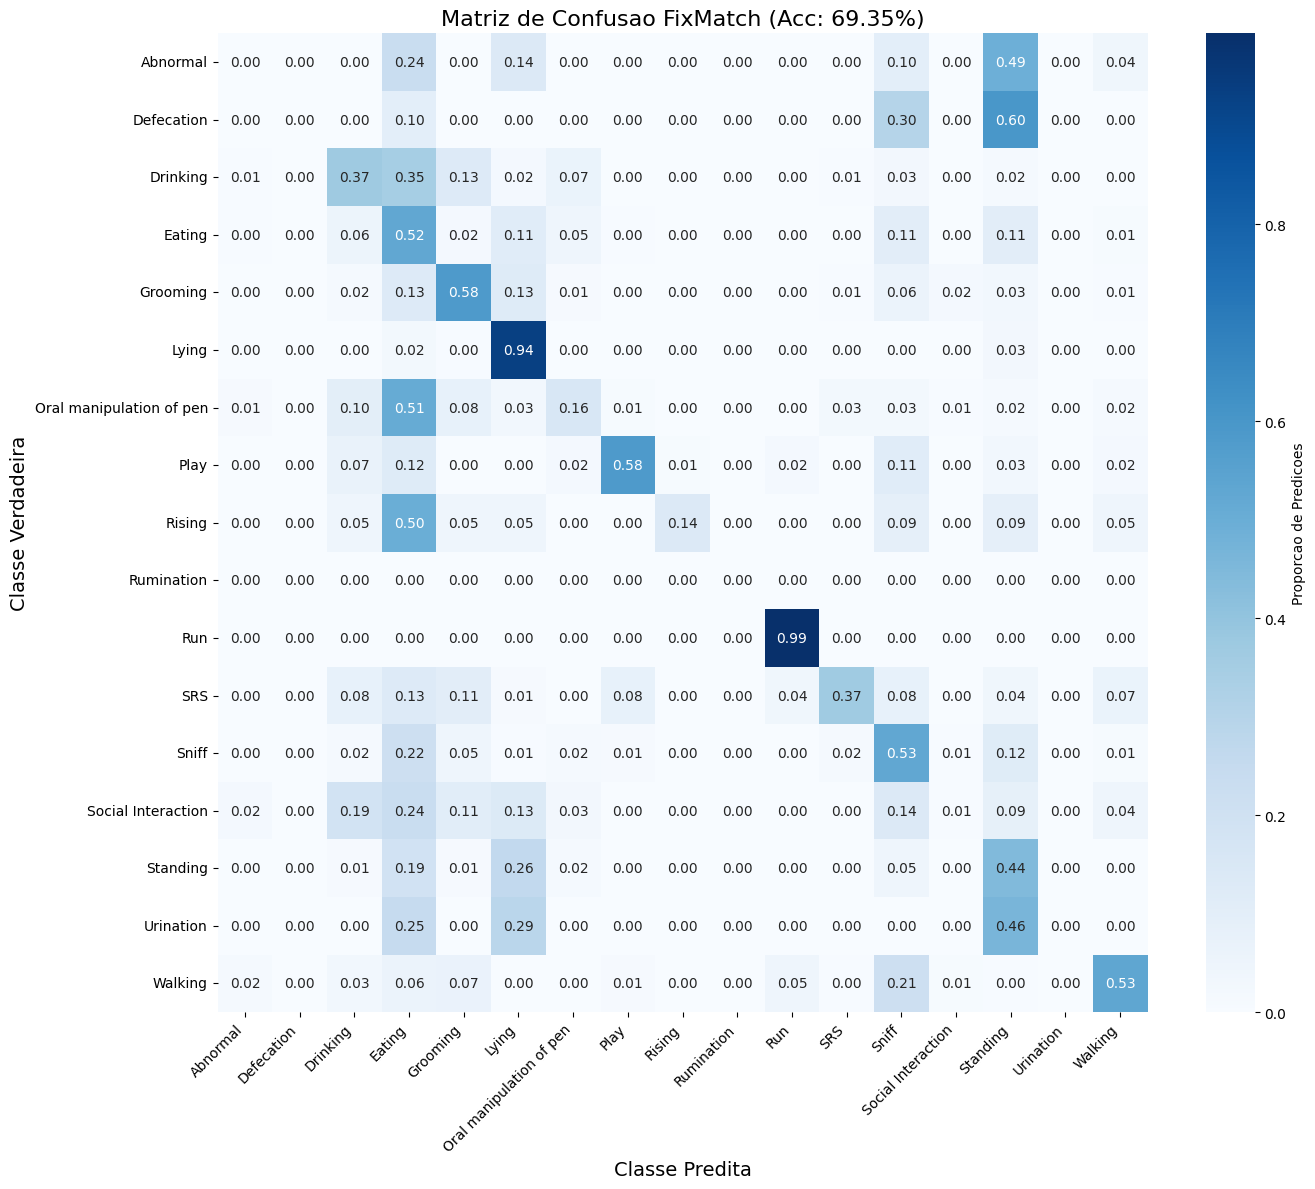

/var/folders/xf/3z7cg77s3r947td4rtbw2y3m0000gn/T/ipykernel_20088/224442338.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Acuracia', y='Comportamento', data=df_acc, palette='viridis')


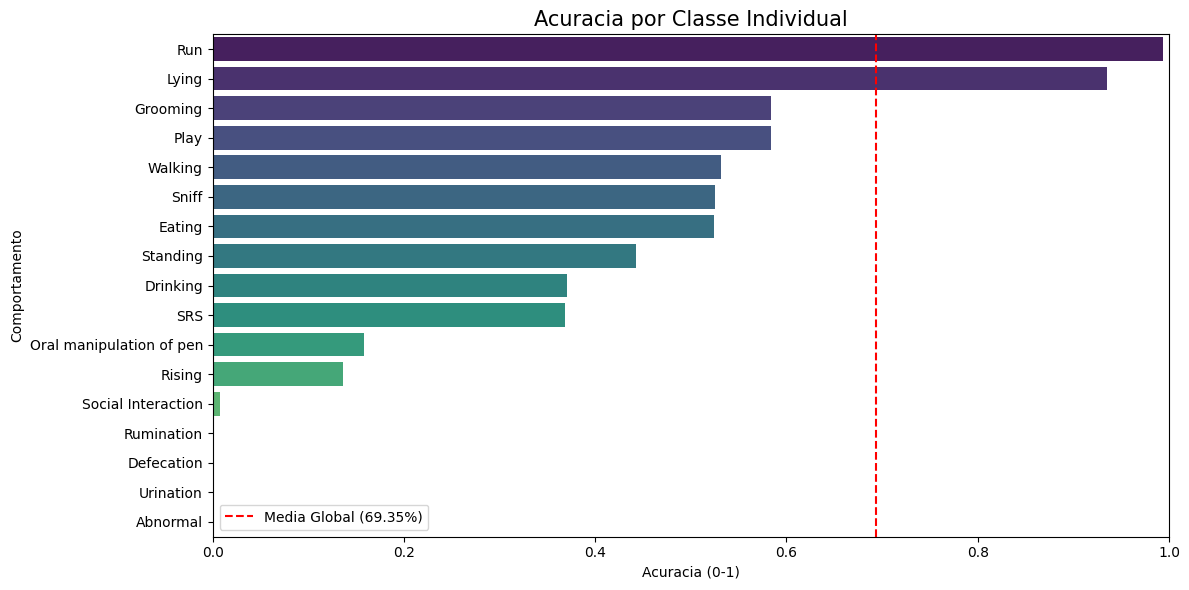

In [41]:
MODEL_PATH = "best_fixmatch_model.pth"
NUM_CLASSES = len(classes)
N_FEATS = 75
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

def evaluate_fixmatch_final(test_loader, class_names):
    print(f"Carregando modelo: {MODEL_PATH}")
    
    # Instancia e Carrega Pesos
    model = TsfelOnlyModel(num_classes=NUM_CLASSES, n_features_tsfel=N_FEATS).to(DEVICE)
    
    if not os.path.exists(MODEL_PATH):
        print("ERRO: Arquivo .pth nao encontrado.")
        return
        
    try:
        state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print("Pesos carregados com sucesso.")
    except Exception as e:
        print(f"Erro ao carregar pesos (verifique arquitetura): {e}")
        return

    model.eval()
    
    y_true = []
    y_pred = []
    probs = []
    
    print("Iniciando inferencia no Test Set...")
    
    with torch.no_grad():
        for x_sig, x_feat, labels in test_loader:
            x_sig = x_sig.to(DEVICE)
            x_feat = x_feat.to(DEVICE)
            labels = labels.to(DEVICE)
            
            # Forward
            outputs = model(x_sig, x_feat)
            
            # Predicao
            _, predicted = torch.max(outputs, 1)
            
            # Guarda na CPU
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            
    # --- RESULTADOS ---
    acc = accuracy_score(y_true, y_pred)
    print("\n" + "="*40)
    print(f"RESULTADO FINAL (FIXMATCH)")
    print("="*40)
    print(f"Acuracia Global: {acc:.2%}")
    print("-" * 40)
    
    # --- MATRIZ DE CONFUSAO ---
    plt.figure(figsize=(14, 12))
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proporcao de Predicoes'})
    
    plt.title(f'Matriz de Confusao FixMatch (Acc: {acc:.2%})', fontsize=16)
    plt.ylabel('Classe Verdadeira', fontsize=14)
    plt.xlabel('Classe Predita', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # --- VISUALIZACAO 2: ACURACIA POR CLASSE ---
    class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-9) 
    df_acc = pd.DataFrame({
        'Comportamento': class_names,
        'Acuracia': class_acc
    }).sort_values('Acuracia', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Acuracia', y='Comportamento', data=df_acc, palette='viridis')
    plt.axvline(acc, color='r', linestyle='--', label=f'Media Global ({acc:.2%})')
    plt.title('Acuracia por Classe Individual', fontsize=15)
    plt.xlabel('Acuracia (0-1)')
    plt.xlim(0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_fixmatch_final(dl_test, classes)